# Random Forest

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, linregress
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

np.random.seed(5140)

In [8]:
# --------------------------------------------------
# 2. Read data
# --------------------------------------------------

filtered_df = pd.read_csv(
    r'C:\GitHub_AI_Workshop\codes\5_yield_prediction\2_ml_models\yield_pani_seed_count.csv'
)

filtered_df = filtered_df.dropna()

filtered_df.head()

,Plot_Pedigree,Plot,Pedigree,Range,Row,Pass,Rep,Yld_ton_ha,GT_Pan_Count,DG_Pan_Count,...,Lab_Pan_Size_cm2,MK_Pan_Size_cm2,Predict_Pan_Size_Pixel,Mach_Seed_Count,Pan_Seed_Count,Reg_Seed_Count,Spr_Seed_Count,Microscope_Area_mm2,DG_Seed_Area_mm2,SKCS_Seed_dia_mm
0,2005-SC964,2005,SC964,2,6,2,1,3.941257,166,129,...,119.284937,71.477387,15499.42034,1839,1276,2041,2006.0,9.947,11.692672,2.410843
1,2009-RTx430BL,2009,RTx430BL,2,10,3,1,4.333421,139,96,...,131.744064,66.349287,14985.00490,882,742,1309,1019.0,12.038,7.009835,3.050454
2,2013-Tx7000,2013,Tx7000,2,14,4,1,5.192731,168,151,...,217.827004,91.675497,15368.33830,2275,1573,1898,2402.0,11.847,16.766636,3.066632
3,2017-RLBK1,2017,RLBK1,2,18,5,1,1.378816,102,103,...,128.253696,45.303214,11945.51458,696,485,1273,727.0,10.234,8.325976,2.603187
4,2021-SC326-6,2021,SC326-6,2,22,6,1,3.612592,139,116,...,301.718209,140.481508,11716.55753,2868,1283,1869,2844.0,10.059,14.686166,2.493731


In [9]:
# --------------------------------------------------
# 3. Define X and y
# --------------------------------------------------

X = filtered_df[
    ['MK_Pan_Size_cm2', 'Pan_Seed_Count', 'DG_Pan_Count', 'DG_Seed_Area_mm2']
].copy()

# Important: use y as 1D Series, not DataFrame
y = filtered_df['Yld_ton_ha'].copy()

In [10]:
y

0      3.941257
1      4.333421
2      5.192731
3      1.378816
4      3.612592
         ...   
103    4.691004
104    2.665269
105    4.819019
106    5.339355
107    4.523373
Name: Yld_ton_ha, Length: 108, dtype: float64

In [11]:
# --------------------------------------------------
# 4. Encode non-numeric columns if present
# --------------------------------------------------

non_numeric_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}

for col in non_numeric_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [12]:
# --------------------------------------------------
# 5. Train Random Forest multiple times and keep best model
# --------------------------------------------------

best_mse = float('inf')
best_model = None
mse_list = []

best_x_test = None
best_y_test = None
best_seed = None

for i in range(10):
    random_seed = np.random.randint(10000)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed
    )

    forest_model = RandomForestRegressor(
        n_estimators=100,
        random_state=random_seed
    )

    forest_model.fit(X_train, y_train)

    y_pred = forest_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

    # For MSE, smaller is better
    if mse < best_mse:
        best_mse = mse
        best_model = forest_model
        best_x_test = X_test
        best_y_test = y_test
        best_seed = random_seed

print(f"Best random seed: {best_seed}")
print("All Mean Squared Errors:", mse_list)
print("Best MSE:", best_mse)

Best random seed: 5635
All Mean Squared Errors: [0.8288377477589237, 0.573482525585262, 0.6669350791344314, 0.5687666038588408, 0.7572695089539502, 0.716707069471375, 1.091202275219767, 0.5969772502865595, 0.8035031945229076, 0.51059616558233]
Best MSE: 0.51059616558233


In [16]:
# --------------------------------------------------
# 6. Detailed test-set results from best model
# --------------------------------------------------

# best_y_pred = best_model.predict(best_x_test)

# individual_mse = (best_y_test.values - best_y_pred) ** 2

# results_df = pd.DataFrame({
#     'Actual_values': best_y_test.values,
#     'Predicted_values': best_y_pred,
#     'MSE': individual_mse
# })

# results_df.head()
# Predict using best model
best_y_pred = best_model.predict(best_x_test)

# Create DataFrame with only Actual and Predicted
df = pd.DataFrame({
    'Actual_values': best_y_test.values,
    'Predicted_values': best_y_pred
})

df.head()

,Actual_values,Predicted_values
0,1.347621,1.671599
1,2.513285,4.081188
2,2.919045,2.845346
3,5.848604,4.100118
4,3.659526,3.821975


In [17]:
df

,Actual_values,Predicted_values
0,1.347621,1.671599
1,2.513285,4.081188
2,2.919045,2.845346
3,5.848604,4.100118
4,3.659526,3.821975
5,3.788660,4.413116
6,2.396743,3.153534
7,0.684335,1.883608
8,3.630843,3.998579
9,1.198293,1.504571


In [ ]:
csv_path = os.path.join(
    os.getcwd(),
    "rf_prediction.csv"
)

df.to_csv(csv_path, index=False)

print(f"CSV saved successfully at: {csv_path}")

CSV saved successfully at: c:\GitHub_AI_Workshop\codes\5_yield_prediction\2_ml_models\rf_prediction_1.csv


# Random Forest

   Actual_values  Predicted_values
0       1.347621          1.671599
1       2.513285          4.081188
2       2.919045          2.845346
3       5.848604          4.100118
4       3.659526          3.821975


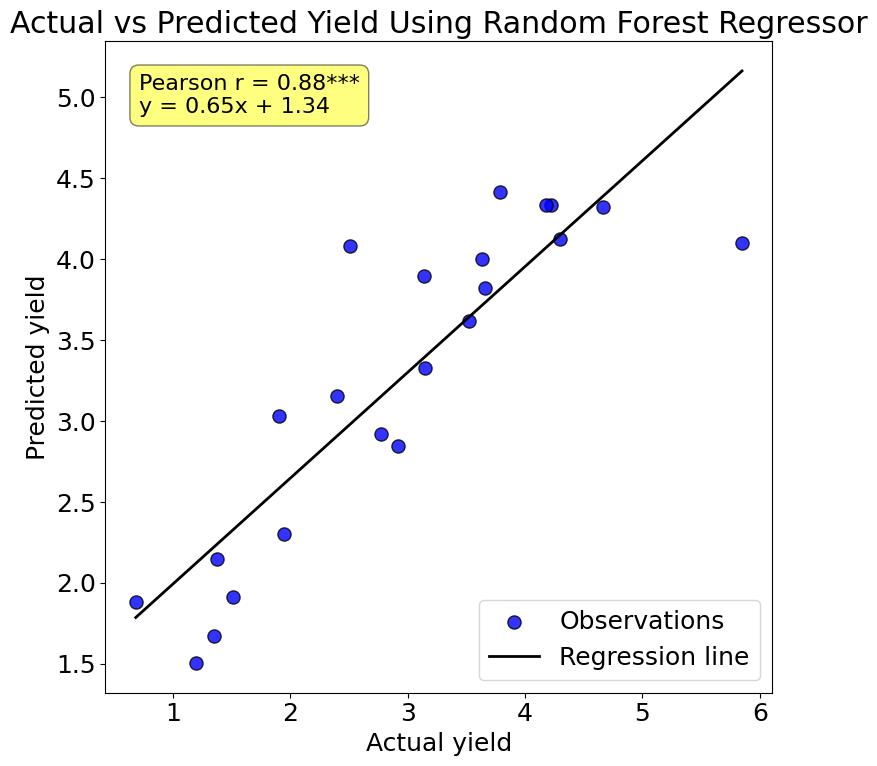

In [20]:
# --------------------------------------------------
# 1. Get predictions from the best Random Forest model
# --------------------------------------------------

test_predictions = best_model.predict(best_x_test)

actual_values = best_y_test.values.ravel()

# --------------------------------------------------
# 2. Calculate statistics
# --------------------------------------------------

correlation, p_value = pearsonr(actual_values, test_predictions)

if p_value < 0.001:
    sig_label = '***'
elif p_value < 0.01:
    sig_label = '**'
elif p_value < 0.05:
    sig_label = '*'
else:
    sig_label = 'ns'

mse = mean_squared_error(actual_values, test_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_values, test_predictions)
r2 = r2_score(actual_values, test_predictions)

slope, intercept, r_value, p_reg, std_err = linregress(
    actual_values, test_predictions
)

x_line = np.linspace(actual_values.min(), actual_values.max(), 200)
y_line = slope * x_line + intercept

# --------------------------------------------------
# 3. Create results dataframe
# --------------------------------------------------

df = pd.DataFrame({
    'Actual_values': actual_values,
    'Predicted_values': test_predictions
})

print(df.head())

# --------------------------------------------------
# 4. Plot Actual vs Predicted
# --------------------------------------------------

plt.rcParams.update({'font.size': 18})

plt.figure(figsize=(8, 8))

plt.scatter(
    actual_values,
    test_predictions,
    color='blue',
    edgecolor='black',
    s=90,
    alpha=0.8,
    label='Observations'
)

# Regression fit line
plt.plot(
    x_line,
    y_line,
    color='black',
    linewidth=2,
    label='Regression line'
)

plt.xlabel('Actual yield')
plt.ylabel('Predicted yield')
plt.title('Actual vs Predicted Yield Using Random Forest Regressor')

text_str = (
    f'Pearson r = {correlation:.2f}{sig_label}\n'
    f'y = {slope:.2f}x + {intercept:.2f}'
)

plt.text(
    0.05,
    0.95,
    text_str,
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='yellow',
        edgecolor='black',
        alpha=0.5
    )
)

plt.legend()
plt.tight_layout()

plt.savefig('RF_actual_vs_predicted_1.png', dpi=300)
plt.show()